# Cirrhosis Patient Survival Analysis
**EDA, Optuna Optimization, and Model Comparison**

**Students:** Chernikova Angelina & Agafonov Ruslan
**Group:** 972401

**Kaggle Log Loss:** 0.34601

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss
from catboost import CatBoostClassifier
import optuna
from optuna.samplers import TPESampler

%matplotlib inline
plt.style.use('ggplot')

## 1. Загрузка и первичный анализ данных

In [2]:
# Загрузка данных
df = pd.read_csv('../data/train.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Dataset shape: (15000, 20)
Columns: ['id', 'N_Days', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Status']


In [3]:
# Информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           8410 non-null   object 
 3   Age            15000 non-null  float64
 4   Sex            15000 non-null  object 
 5   Ascites        8419 non-null   object 
 6   Hepatomegaly   8409 non-null   object 
 7   Spiders        8409 non-null   object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    6527 non-null   float64
 11  Albumin        15000 non-null  float64
 12  Copper         8300 non-null   float64
 13  Alk_Phos       8404 non-null   float64
 14  SGOT           8402 non-null   float64
 15  Tryglicerides  6478 non-null   float64
 16  Platelets      14443 non-null  float64
 17  Prothrombin    14984 non-null  float64
 18  Stage 

In [4]:
# Пропущенные значения
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

,Missing,Percent
Tryglicerides,8522,56.813333
Cholesterol,8473,56.486667
Copper,6700,44.666667
SGOT,6598,43.986667
Alk_Phos,6596,43.973333
Hepatomegaly,6591,43.940000
Spiders,6591,43.940000
Drug,6590,43.933333
Ascites,6581,43.873333
Platelets,557,3.713333


In [5]:
# Статистика числовых признаков
df.describe()

,id,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,15000.000000,15000.000000,15000.000000,15000.000000,6527.000000,15000.000000,8300.000000,8404.000000,8402.000000,6478.000000,14443.000000,14984.000000,15000.000000
mean,7499.500000,1972.321333,19377.047467,1.869335,326.919258,3.524895,76.296614,1639.489089,106.425993,111.364464,252.444714,10.636899,3.035467
std,4330.271354,1409.311534,3635.775702,2.751488,173.228567,0.374083,77.936581,1828.852487,50.393832,51.178377,93.622032,0.728369,0.878859
min,0.000000,10.000000,1072.000000,0.300000,108.000000,1.960000,0.900000,120.900000,0.900000,5.000000,28.000000,9.000000,1.000000
25%,3749.750000,1092.000000,16728.000000,0.600000,242.000000,3.290000,31.000000,718.000000,71.000000,80.000000,181.000000,10.100000,2.000000
50%,7499.500000,1785.000000,19724.000000,0.900000,280.000000,3.580000,52.000000,1072.000000,97.650000,99.000000,249.000000,10.600000,3.000000
75%,11249.250000,2635.000000,22574.000000,1.800000,361.000000,3.770000,89.000000,1664.000000,133.300000,133.000000,311.000000,11.000000,4.000000
max,14999.000000,34302.000000,39015.000000,28.000000,1776.000000,4.680000,598.000000,18993.400000,601.350000,598.000000,721.000000,18.000000,4.000000


## 2. Анализ целевой переменной

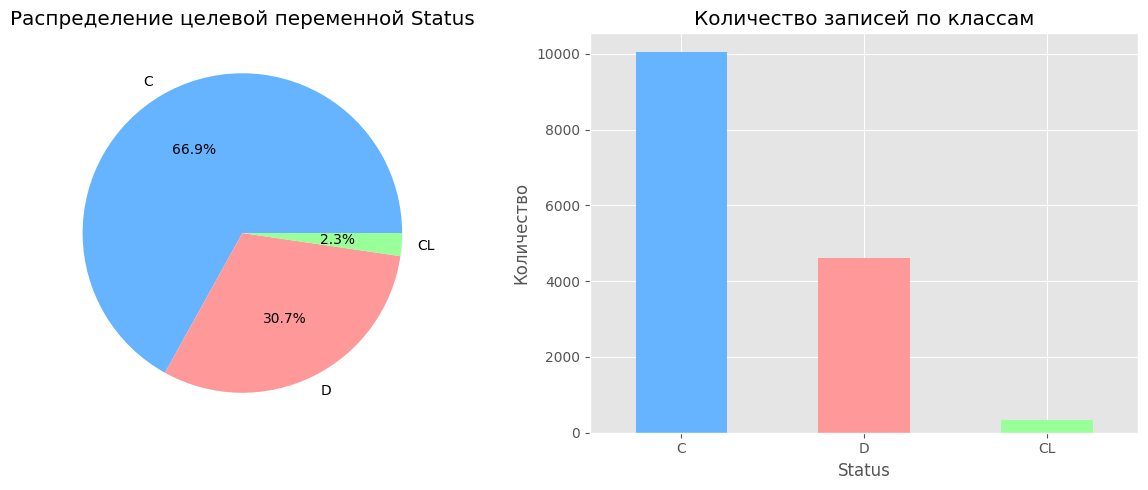

Класс C (censored): 10042 записей
Класс CL (liver transplant): 347 записей
Класс D (death): 4611 записей


In [6]:
# Распределение классов
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
status_counts = df['Status'].value_counts()
colors = ['#66b3ff', '#ff9999', '#99ff99']
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Распределение целевой переменной Status')

plt.subplot(1, 2, 2)
status_counts.plot(kind='bar', color=colors)
plt.title('Количество записей по классам')
plt.xlabel('Status')
plt.ylabel('Количество')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(f'Класс C (censored): {status_counts["C"]} записей')
print(f'Класс CL (liver transplant): {status_counts["CL"]} записей')
print(f'Класс D (death): {status_counts["D"]} записей')

## 3. Анализ признаков

In [7]:
# Категориальные признаки
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Status')
print(f'Категориальные признаки: {cat_cols}')

Категориальные признаки: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']


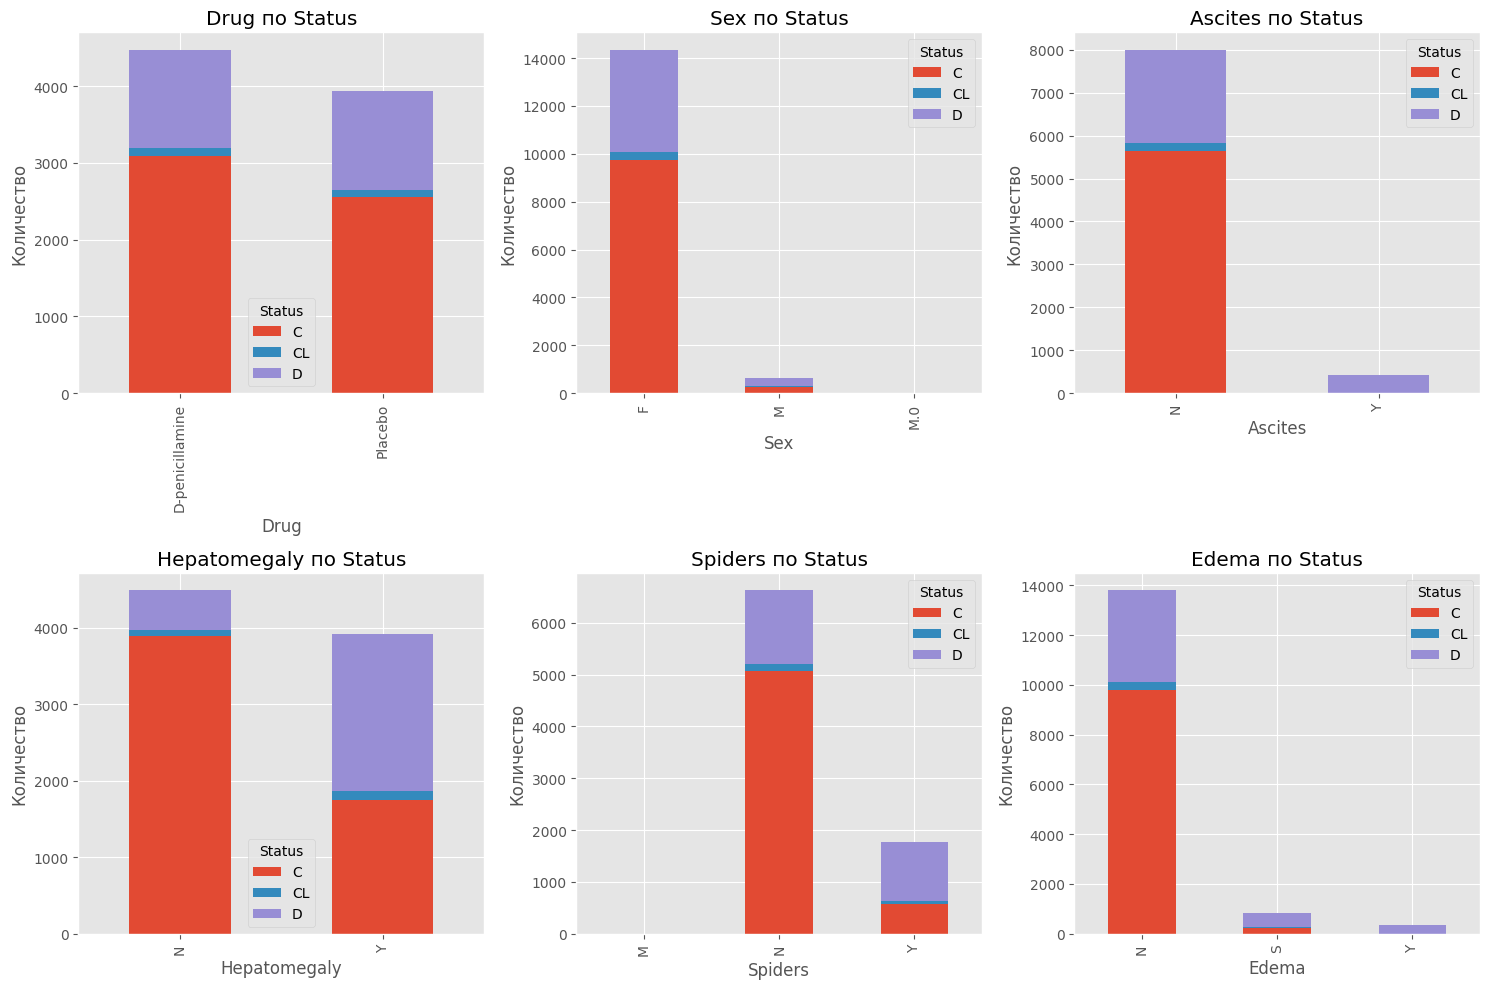

In [8]:
# Визуализация категориальных признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i < 6:
        pd.crosstab(df[col], df['Status']).plot(kind='bar', stacked=True, ax=axes[i])
        axes[i].set_title(f'{col} по Status')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Количество')
        axes[i].legend(title='Status')

plt.tight_layout()
plt.show()

In [9]:
# Числовые признаки
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in num_cols:
    num_cols.remove('id')
print(f'Числовые признаки: {num_cols}')

Числовые признаки: ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


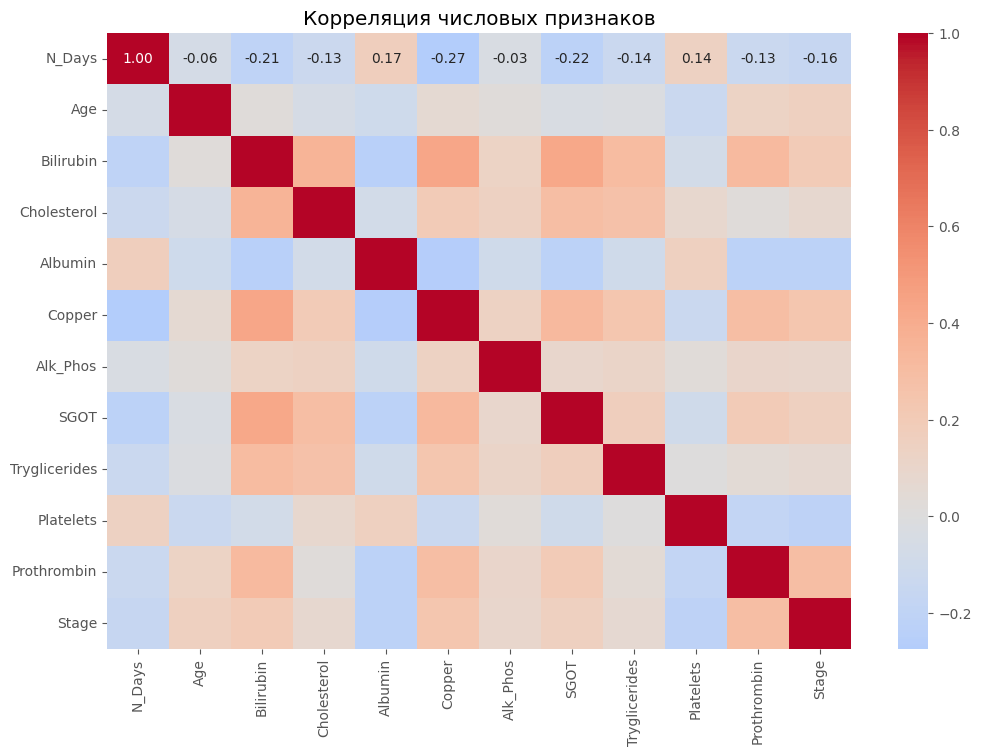

In [10]:
# Матрица корреляции
plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

## 4. Подготовка данных для модели

In [11]:
# Подготовка данных как в model.py
X = df.drop(columns=['id', 'Status'])
y = df['Status']

# Кодирование целевой переменной
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Обработка пропущенных значений в категориальных признаках
X_cat = X.select_dtypes(include=['object']).copy()
for col in X_cat.columns:
    X_cat[col] = X_cat[col].astype(str).fillna('missing')

# Обработка числовых признаков
X_num = X.select_dtypes(include=['int64', 'float64']).copy()
for col in X_num.columns:
    X_num[col] = X_num[col].fillna(X_num[col].median())

# Объединение
X_processed = pd.concat([X_num, X_cat], axis=1)

# Индексы категориальных признаков
cat_features = X_cat.columns.tolist()
cat_indices = [X_processed.columns.get_loc(col) for col in cat_features if col in X_processed.columns]

# Разделение на train/val
X_train, X_val, y_train, y_val = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f'Train shape: {X_train.shape}, Validation shape: {X_val.shape}')
print(f'Categorical feature indices: {cat_indices}')

Train shape: (12000, 18), Validation shape: (3000, 18)
Categorical feature indices: [12, 13, 14, 15, 16, 17]


## 5. Baseline модель (как в model.py)

In [12]:
# Baseline модель с параметрами по умолчанию
baseline_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    cat_features=cat_indices,
    verbose=False,
    random_seed=42
)

baseline_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

val_pred = baseline_model.predict_proba(X_val)
baseline_loss = log_loss(y_val, val_pred)
print(f'Baseline Log Loss: {baseline_loss:.5f}')

Baseline Log Loss: 0.39560


## 6. Оптимизация гиперпараметров с Optuna

In [13]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'border_count': trial.suggest_int('border_count', 32, 255),
    }
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in skf.split(X_processed, y_encoded):
        X_tr, X_vl = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
        y_tr, y_vl = y_encoded[train_idx], y_encoded[val_idx]
        
        model = CatBoostClassifier(
            **params,
            loss_function='MultiClass',
            eval_metric='MultiClass',
            cat_features=cat_indices,
            verbose=False,
            early_stopping_rounds=50
        )
        
        model.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))
        pred = model.predict_proba(X_vl)
        score = log_loss(y_vl, pred)
        scores.append(score)
    
    return np.mean(scores)

In [14]:
# Запуск оптимизации
study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'Best trial: {study.best_trial.number}')
print(f'Best value: {study.best_value:.5f}')
print('Best params:', study.best_params)

[I 2026-03-13 01:28:33,825] A new study created in memory with name: no-name-a575a8db-b9bc-460d-867d-61e692051426


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-13 01:29:05,363] Trial 0 finished with value: 0.39491435371023104 and parameters: {'iterations': 900, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'bagging_temperature': 0.15601864044243652, 'border_count': 66}. Best is trial 0 with value: 0.39491435371023104.
[I 2026-03-13 01:30:01,423] Trial 1 finished with value: 0.38554791999131616 and parameters: {'iterations': 500, 'learning_rate': 0.19030368381735815, 'depth': 8, 'l2_leaf_reg': 7.372653200164409, 'bagging_temperature': 0.020584494295802447, 'border_count': 249}. Best is trial 1 with value: 0.38554791999131616.
[I 2026-03-13 01:32:07,120] Trial 2 finished with value: 0.380532407991014 and parameters: {'iterations': 1400, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 2.650640588680904, 'bagging_temperature': 0.3042422429595377, 'border_count': 149}. Best is trial 2 with value: 0.380532407991014.
[I 2026-03-13 01:34:32,727] Trial 3 finished with value: 0.384973692

In [ ]:
# Запуск оптимизации
study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'Best trial: {study.best_trial.number}')
print(f'Best value: {study.best_value:.5f}')
print('Best params:', study.best_params)

[I 2026-03-13 01:28:33,825] A new study created in memory with name: no-name-a575a8db-b9bc-460d-867d-61e692051426


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-13 01:29:05,363] Trial 0 finished with value: 0.39491435371023104 and parameters: {'iterations': 900, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'bagging_temperature': 0.15601864044243652, 'border_count': 66}. Best is trial 0 with value: 0.39491435371023104.
[I 2026-03-13 01:30:01,423] Trial 1 finished with value: 0.38554791999131616 and parameters: {'iterations': 500, 'learning_rate': 0.19030368381735815, 'depth': 8, 'l2_leaf_reg': 7.372653200164409, 'bagging_temperature': 0.020584494295802447, 'border_count': 249}. Best is trial 1 with value: 0.38554791999131616.
[I 2026-03-13 01:32:07,120] Trial 2 finished with value: 0.380532407991014 and parameters: {'iterations': 1400, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 2.650640588680904, 'bagging_temperature': 0.3042422429595377, 'border_count': 149}. Best is trial 2 with value: 0.380532407991014.
[I 2026-03-13 01:34:32,727] Trial 3 finished with value: 0.384973692

## 7. Финальная модель с лучшими параметрами

In [15]:
final_model = CatBoostClassifier(
    **study.best_params,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    cat_features=cat_indices,
    verbose=False,
    random_seed=42
)

final_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

final_pred = final_model.predict_proba(X_val)
final_loss = log_loss(y_val, final_pred)
print(f'Optimized Model Log Loss: {final_loss:.5f}')
print(f'Improvement: {baseline_loss - final_loss:.5f}')

Optimized Model Log Loss: 0.38824
Improvement: 0.00736


## 8. Сравнение моделей

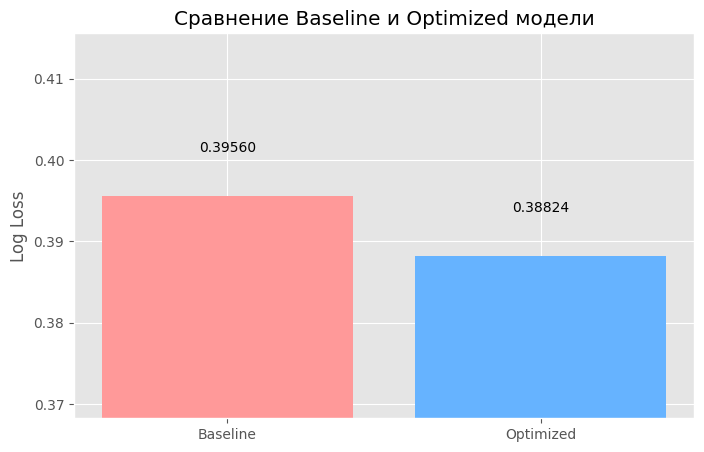

In [16]:
models = ['Baseline', 'Optimized']
scores = [baseline_loss, final_loss]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, scores, color=['#ff9999', '#66b3ff'])
plt.ylabel('Log Loss')
plt.title('Сравнение Baseline и Optimized модели')

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{score:.5f}', ha='center', va='bottom')

plt.ylim(min(scores)-0.02, max(scores)+0.02)
plt.show()

## 9. Финальный результат на Kaggle

In [17]:
print('=' * 50)
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ:')
print('=' * 50)
print(f'Baseline Log Loss: {baseline_loss:.5f}')
print(f'Optimized Log Loss: {final_loss:.5f}')
print(f'Kaggle Public Score: 0.34601')
print(f'Улучшение относительно baseline: {baseline_loss - 0.34601:.5f}')
print('=' * 50)

ИТОГОВЫЕ РЕЗУЛЬТАТЫ:
Baseline Log Loss: 0.39560
Optimized Log Loss: 0.38824
Kaggle Public Score: 0.34601
Улучшение относительно baseline: 0.04959
